In [28]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from typing import TypedDict, Annotated

import requests
import math
import os
from dotenv import load_dotenv
load_dotenv() 

True

In [29]:
endpoint = "https://models.github.ai/inference"
llm = ChatOpenAI(base_url=endpoint,model_name = "openai/gpt-4o-mini")

In [30]:
search_tool = TavilySearch(
    max_results=5,
    topic="general",
    search_depth="advanced"
)

@tool
def calculator(expression: str) -> str:
    """
    Useful for simple math calculations.
    Input should be a valid math expression.
    Example: 2+2, sqrt(16), 10*5
    """
    try:
        allowed_names = {
            k: v
            for k, v in math.__dict__.items()
            if not k.startswith("__")
        }

        result = eval(
            expression,
            {"__builtins__": {}},
            allowed_names
        )

        return str(result)

    except Exception as e:
        return f"Calculation error: {str(e)}"


 

@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch the latest stock price for a given symbol (e.g. AAPL, TSLA).

    Returns:
    {
        "symbol": "AAPL",
        "price": "213.55",
        "change": "-1.23",
        "change_percent": "-0.57%",
        "volume": "53492012",
        "latest_trading_day": "2026-06-24"
    }
    """
    api_key = os.getenv("ALPHA_VANTAGE_API_KEY")

    if not api_key:
        return {"error": "ALPHA_VANTAGE_API_KEY not configured"}

    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE"
        f"&symbol={symbol.upper()}"
        f"&apikey={api_key}"
    )

    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        data = response.json()

        quote = data.get("Global Quote")

        if not quote:
            return {
                "error": f"No data found for symbol '{symbol}'"
            }

        return {
            "symbol": quote.get("01. symbol"),
            "price": quote.get("05. price"),
            "change": quote.get("09. change"),
            "change_percent": quote.get("10. change percent"),
            "volume": quote.get("06. volume"),
            "latest_trading_day": quote.get("07. latest trading day"),
        }

    except requests.RequestException as e:
        return {"error": f"Request failed: {str(e)}"}

    except Exception as e:
        return {"error": str(e)}

In [31]:
tools = [search_tool, calculator, get_stock_price]

In [32]:
llm_with_tools = llm.bind_tools(tools)

In [33]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [34]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [35]:
tool_node = ToolNode(tools)

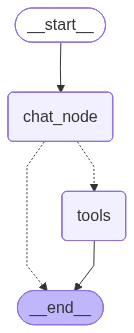

In [41]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
# graph.add_edge('tools', 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()
chatbot

In [37]:
while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    initial_state = {
        "messages" : [HumanMessage(content=input_msg)]
    }
    response = chatbot.invoke(initial_state)["messages"][-1].content
    print(": ", response)

>  check about tsla stock


:  {"symbol": "TSLA", "price": "375.5300", "change": "-6.0800", "change_percent": "-1.5932%", "volume": "37081421", "latest_trading_day": "2026-06-24"}


>  what about the trump ear


:  {"query": "Trump ear", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://time.com/7003617/trump-ear-injury-shooting-details", "title": "Trump's Ear Wound: What We Do and Don't Know", "content": "Trump’s ear wound from an assassination attempt at a rally on July 13 quickly became a symbol of solidarity for many of his supporters, and a grim reminder of political violence in the U.S.\n\nTrump’s team has largely remained tight-lipped about the ear wound, refraining from publicly sharing the former President’s medical records or conducting a press briefing at the Pennsylvania hospital where he was treated. The Trump campaign did not respond to a request for comment.\n\nBut comments by FBI Director Christopher Wray on July 24 indicated there might be more the American public did not know about the injury. Wray suggested in congressional testimony that the wound may have been caused by shrapnel, while Trump and his former White House physician had sai

>  5+5/2


:  7.5


>  sin(3.14)


:  0.0015926529164868282


>  q


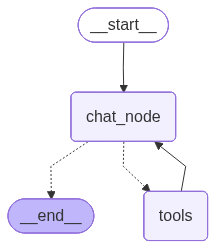

In [38]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')
graph.add_edge('chat_node', END)
chatbot = graph.compile()
chatbot

In [39]:
while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    initial_state = {
        "messages" : [HumanMessage(content=input_msg)]
    }
    response = chatbot.invoke(initial_state)["messages"][-1].content
    print(": ", response)

>  check about tsla stock


:  The latest stock price for Tesla (TSLA) is $375.53. It has decreased by $6.08, which is a change of -1.59%. The trading volume for the latest trading day was 37,081,421 shares.


>  q


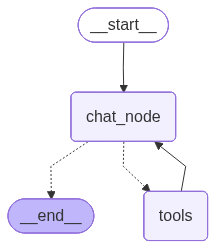

In [43]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')
graph.add_edge('chat_node', END)

from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [46]:
thread = "1"
while True:
    input_msg = input("> ")

    if input_msg in ["q"]:
        break
    initial_state = {
        "messages" : [HumanMessage(content=input_msg)]
    }
    config = {
        "configurable":{"thread_id": thread}
    }
    response = chatbot.invoke(initial_state, config=config)["messages"][-1].content
    print(": ", response)

>  check tsla stock


:  The latest stock price for Tesla (TSLA) is $375.53. It has decreased by $6.08, which is a change of -1.59%. The trading volume for the latest day was 37,081,421 shares.


>  q


In [49]:
list(chatbot.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='check tsla stock', additional_kwargs={}, response_metadata={}, id='e48972bd-3853-426d-aa10-0af7505ab735'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 1329, 'total_tokens': 1346, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1280}, 'latency_checkpoint': {'engine_tbt_ms': 29, 'engine_ttft_ms': 398, 'engine_ttlt_ms': 884, 'pre_inference_ms': 147, 'service_tbt_ms': 29, 'service_ttft_ms': 1139, 'service_ttlt_ms': 1620, 'total_duration_ms': 1481, 'user_visible_ttft_ms': 993}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4dcfea0a44', 'id': 'chatcmpl-DuWx5iWj21dlDU6J82wD5Ht16AF0j', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logp